### import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
data= pd.read_csv(r"C:\Users\dell\Downloads\archive (1)\loan_prediction.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [5]:
data.shape

(614, 13)

In [6]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
data['Gender'].value_counts(normalize=True, dropna=False)*100

Gender
Male      79.641694
Female    18.241042
NaN        2.117264
Name: proportion, dtype: float64

In [10]:
data['Married'].value_counts(normalize=True, dropna=False)*100

Married
Yes    64.820847
No     34.690554
NaN     0.488599
Name: proportion, dtype: float64

In [11]:
data['Dependents'].value_counts(normalize=True, dropna=False)*100

Dependents
0      56.188925
1      16.612378
2      16.449511
3+      8.306189
NaN     2.442997
Name: proportion, dtype: float64

In [12]:
data['Self_Employed'].value_counts(normalize=True, dropna=False)*100

Self_Employed
No     81.433225
Yes    13.355049
NaN     5.211726
Name: proportion, dtype: float64

In [13]:
data['Credit_History'].value_counts(normalize=True, dropna=False)*100

Credit_History
1.0    77.361564
0.0    14.495114
NaN     8.143322
Name: proportion, dtype: float64

In [14]:
# Target variable

loan_status_counts = data['Loan_Status'].value_counts(normalize=True, dropna=False)*100
loan_status_counts

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

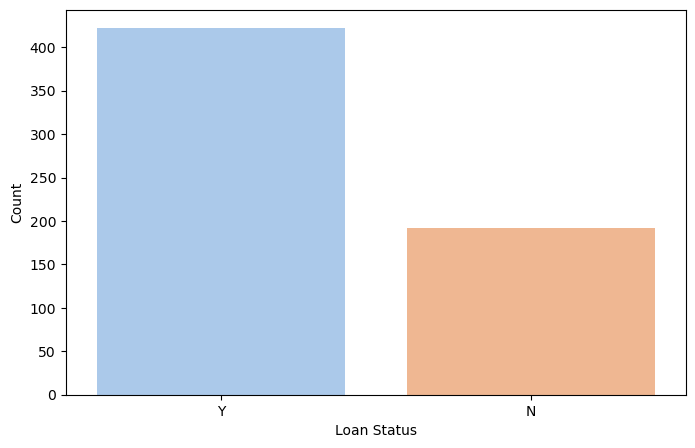

In [15]:
# Count values for Loan_Status
loan_status_counts = data['Loan_Status'].value_counts().reset_index()
loan_status_counts.columns = ['Loan_Status', 'Count']

# Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(data=loan_status_counts, x='Loan_Status', y='Count', palette='pastel')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [16]:
Loan_Status_summary = data.groupby('Loan_Status').count()[['Gender','Married','Dependents','Education','Credit_History']].sort_values(by=['Loan_Status'], ascending= False).reset_index()
Loan_Status_summary 

,Loan_Status,Gender,Married,Dependents,Education,Credit_History
0,Y,414,419,413,422,385
1,N,187,192,186,192,179


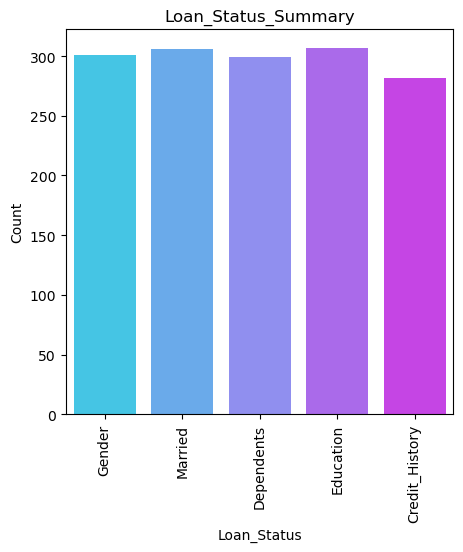

In [17]:
plt.figure(figsize=(5,5))
sns.barplot(data=Loan_Status_summary, palette='cool',errorbar=None)
plt.title('Loan_Status_Summary')
plt.xlabel('Loan_Status')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [18]:
pivot_data= data.pivot_table(values=['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History'], index='Loan_Status', aggfunc='count').reset_index()
pivot_data

,Loan_Status,ApplicantIncome,CoapplicantIncome,Credit_History,LoanAmount,Loan_Amount_Term
0,N,192,192,179,181,186
1,Y,422,422,385,411,414


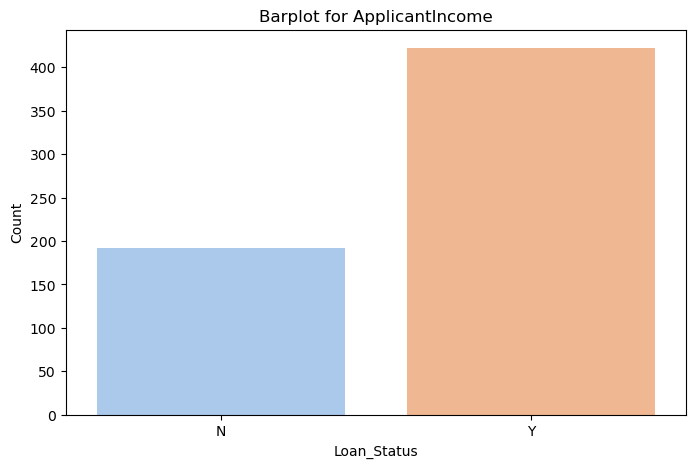

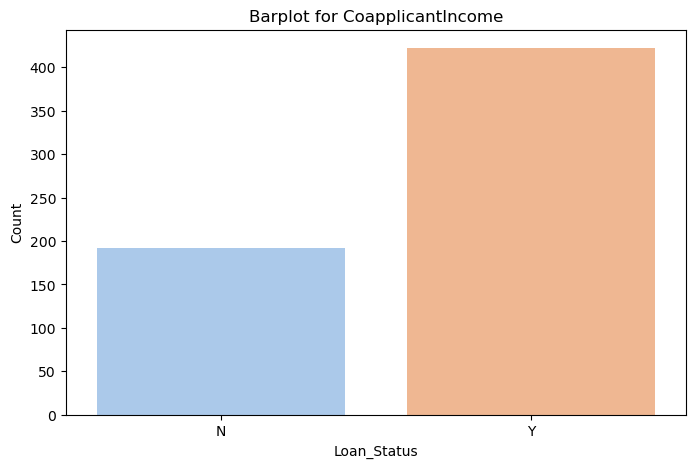

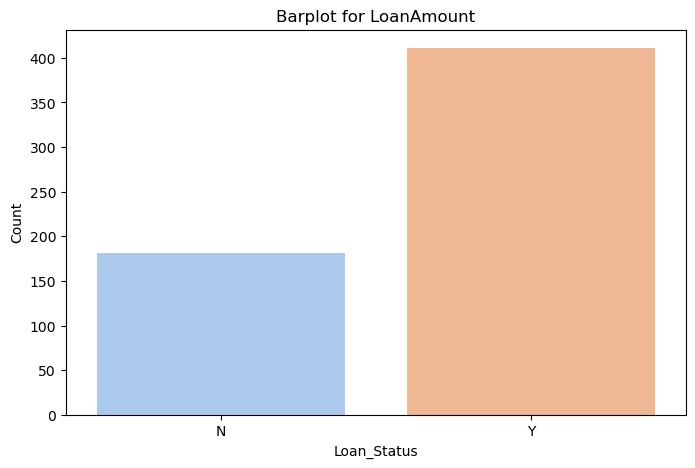

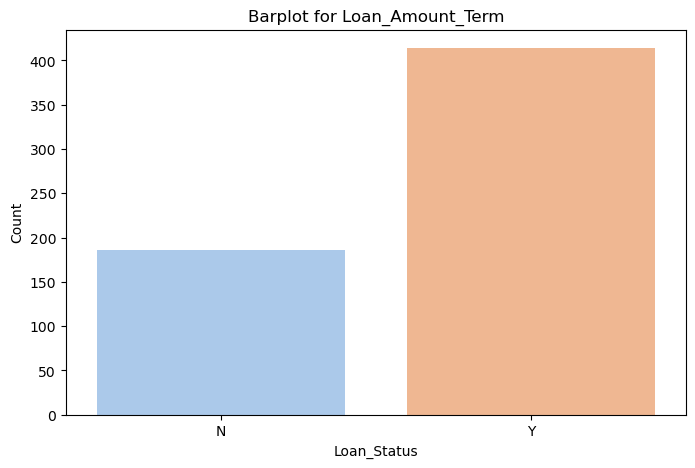

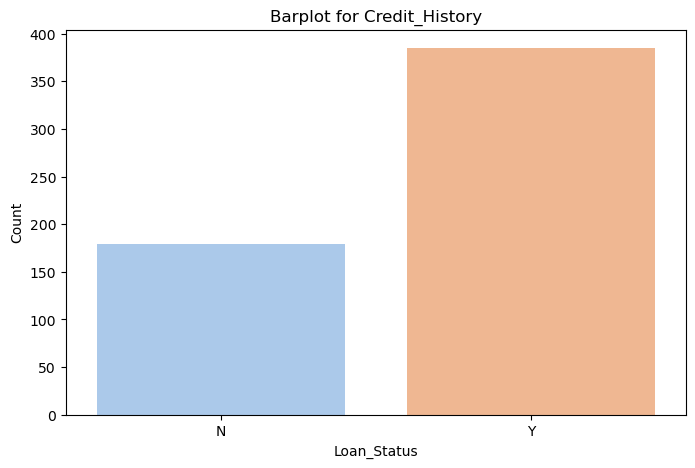

In [19]:
values=['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

for i in values:
    plt.figure(figsize=(8,5))
    sns.barplot(x='Loan_Status', y=i, data=pivot_data, palette='pastel')
    plt.title(f'Barplot for {i}')
    plt.xlabel('Loan_Status')
    plt.ylabel('Count')
    plt.show()

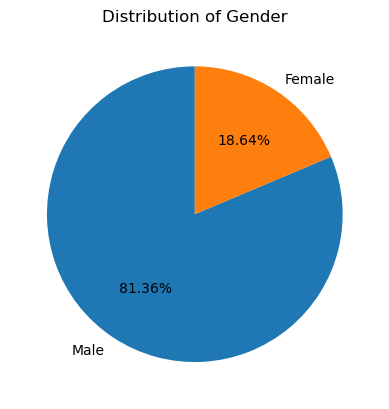

In [20]:
gender_counts= data['Gender'].value_counts()

plt.pie(gender_counts, labels= gender_counts.index, autopct= '%.2f%%', startangle=90)
plt.title('Distribution of Gender')
plt.show()

### checking the outliers

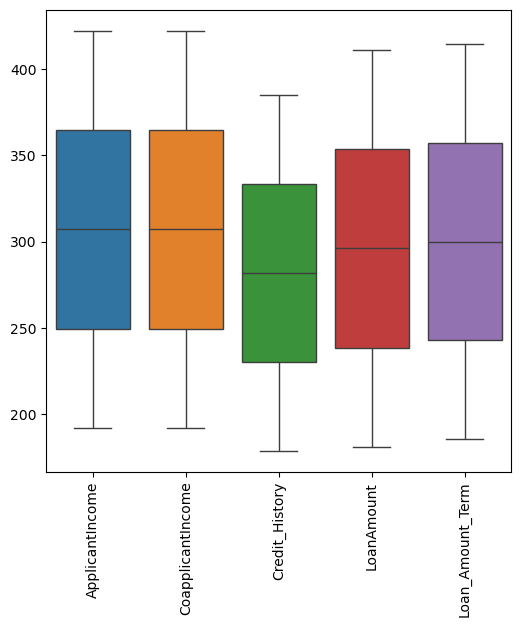

In [22]:
plt.figure(figsize=(6,6))
sns.boxplot(data=pivot_data)
plt.xticks(rotation=90)
plt.show()

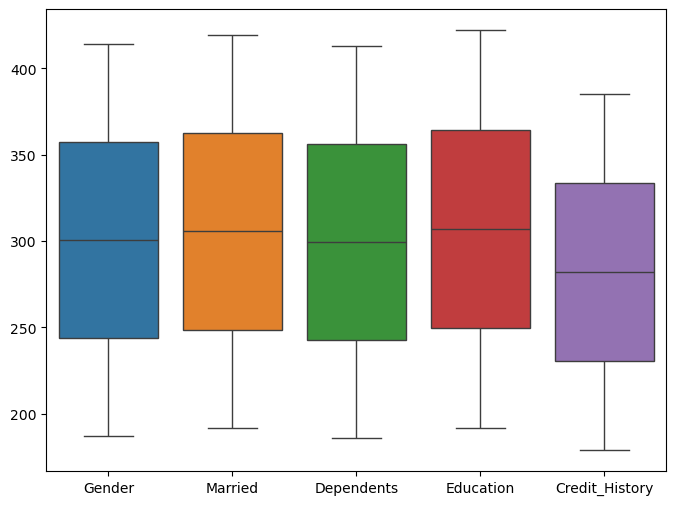

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(data=Loan_Status_summary)
plt.show()

### fill the null values

In [25]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [26]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [27]:
cat_cols=['Gender','Married','Self_Employed','Dependents']
num_cols=['LoanAmount','Loan_Amount_Term','Credit_History']

In [28]:
for i in cat_cols:
    data[i].fillna(data[i].mode()[0],inplace=True)

In [29]:
data.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [30]:
for col in num_cols:
    data[col].fillna(data[col].mean(),inplace=True)

In [31]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

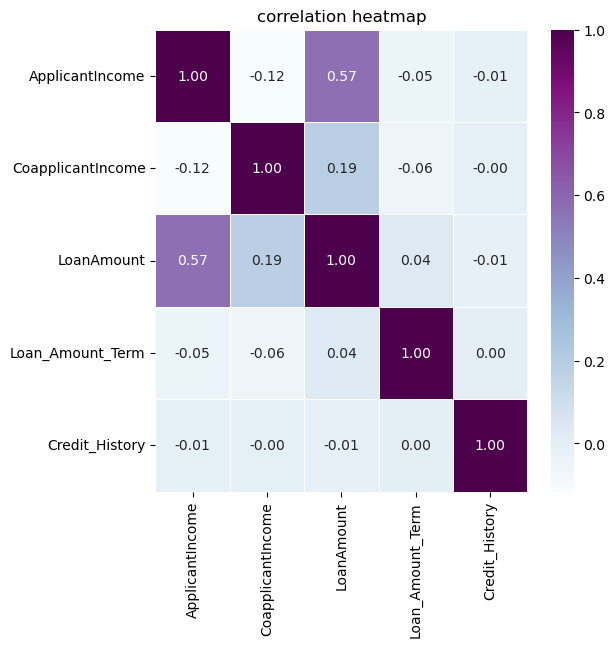

In [32]:
corr= data.corr(numeric_only=True)
plt.figure(figsize=(6,6))
sns.heatmap(corr,annot=True, cmap='BuPu', fmt='.2f',linewidth=0.5)
plt.title('correlation heatmap')
plt.show()

## Feature Engineering

In [34]:
data['Total_Income']=  data['ApplicantIncome'] + data['CoapplicantIncome']
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0


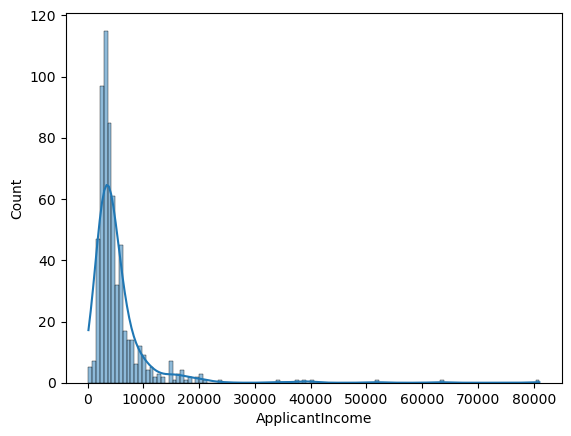

In [35]:
sns.histplot(data['ApplicantIncome'],kde=True)
plt.show()

### Apply Log Transformation 

In [37]:
# as we can see that there is right-skewed distribution
# we will apply log transformation : Log Transformation is a data processing technique used mainly for numerical features
# to make them suitable for analysis.
# log transformation makes the distribution more normal 
# used to reduce skewness, handle outliers, stablize variance in numerical data
# helps linear models to perform better by making the data distribution closer to normal and improving relationships b/w variables

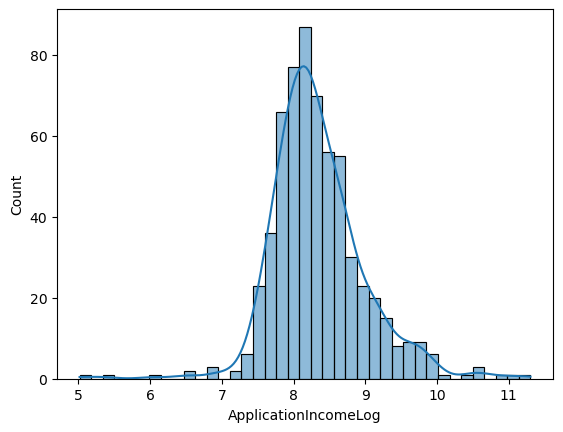

In [38]:
data['ApplicationIncomeLog']= np.log(data['ApplicantIncome']+1)
sns.histplot(data['ApplicationIncomeLog'], kde=True)
plt.show()

In [39]:
data['LoanAmountLog']= np.log(data['LoanAmount']+1)
data['LoanAmountTermLog']= np.log(data['Loan_Amount_Term']+1)
data['Total_Income']=np.log(data['Total_Income']+1)

In [40]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,ApplicationIncomeLog,LoanAmountLog,LoanAmountTermLog
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,7.972811,7.972811,4.276666,5.888878
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,8.320448,8.320448,3.713572,5.198497
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,9.025576,8.996280,5.537334,5.888878
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,8.933796,8.933796,5.236442,5.888878
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N,8.430327,8.430327,4.897840,5.888878


In [41]:
# dropping unnecessary columns

cols= ['Loan_ID','ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Total_Income']

data_new= data.drop(columns=cols,axis=1)

In [42]:
data_new.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicationIncomeLog,LoanAmountLog,LoanAmountTermLog
0,Male,No,0,Graduate,No,1.0,Urban,Y,8.674197,4.993232,5.888878
1,Male,Yes,1,Graduate,No,1.0,Rural,N,8.430327,4.859812,5.888878
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,8.006701,4.204693,5.888878
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.857094,4.795791,5.888878
4,Male,No,0,Graduate,No,1.0,Urban,Y,8.699681,4.955827,5.888878


### Encoding

In [85]:
from sklearn .preprocessing import LabelEncoder
cols= ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']

le=LabelEncoder()
for col in cols:
    data_new[col]= le.fit_transform(data_new[col])

In [91]:
data_new.head()
#data_new.tail()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicationIncomeLog,LoanAmountLog,LoanAmountTermLog
0,1,0,0,0,0,1.0,2,1,8.674197,4.993232,5.888878
1,1,1,1,0,0,1.0,0,0,8.430327,4.859812,5.888878
2,1,1,0,0,1,1.0,2,1,8.006701,4.204693,5.888878
3,1,1,0,1,0,1.0,2,1,7.857094,4.795791,5.888878
4,1,0,0,0,0,1.0,2,1,8.699681,4.955827,5.888878


In [95]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                614 non-null    int32  
 1   Married               614 non-null    int32  
 2   Dependents            614 non-null    object 
 3   Education             614 non-null    int32  
 4   Self_Employed         614 non-null    int32  
 5   Credit_History        614 non-null    float64
 6   Property_Area         614 non-null    int32  
 7   Loan_Status           614 non-null    int32  
 8   ApplicationIncomeLog  614 non-null    float64
 9   LoanAmountLog         614 non-null    float64
 10  LoanAmountTermLog     614 non-null    float64
dtypes: float64(4), int32(6), object(1)
memory usage: 38.5+ KB


In [99]:
data_new['Dependents']= data_new['Dependents'].replace('3+',3)
data_new['Dependents']= data_new['Dependents'].astype(int)

In [101]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                614 non-null    int32  
 1   Married               614 non-null    int32  
 2   Dependents            614 non-null    int32  
 3   Education             614 non-null    int32  
 4   Self_Employed         614 non-null    int32  
 5   Credit_History        614 non-null    float64
 6   Property_Area         614 non-null    int32  
 7   Loan_Status           614 non-null    int32  
 8   ApplicationIncomeLog  614 non-null    float64
 9   LoanAmountLog         614 non-null    float64
 10  LoanAmountTermLog     614 non-null    float64
dtypes: float64(4), int32(7)
memory usage: 36.1 KB


### Splitting the Dependent and Independent

In [104]:
x= data_new.drop(columns=['Loan_Status'],axis=1)
y= data_new['Loan_Status']

### building the model

In [116]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [122]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size = 0.25, random_state=42)

In [202]:
# Logistic Regression

model1= LogisticRegression()
model1.fit(x_train,y_train)
y_pred_model1= model1.predict(x_test)
accuracy= accuracy_score(y_test,y_pred_model1)
print(f'Logistic Regression accuracy Accuracy_score : {accuracy*100}')

Logistic Regression accuracy Accuracy_score : 77.27272727272727


In [204]:
score= cross_val_score(model1,x,y,cv=5)
print(f'Score: {score}')
print(np.mean(score)*100)

Score: [0.81300813 0.7804878  0.7804878  0.86178862 0.81967213]
81.10888977742236


In [206]:
# DecisionTree

model2= DecisionTreeClassifier()
model2.fit(x_train,y_train)
y_pred_model2= model2.predict(x_test)
accuracy= accuracy_score(y_test,y_pred_model2)
print(f'Decision Tree Classifier Accuracy_score : {accuracy*100}')

Decision Tree Classifier Accuracy_score : 72.07792207792207


In [208]:
score=cross_val_score(model2,x,y, cv=5)
print(f'Score: {score}')
print(np.mean(score)*100)

Score: [0.69918699 0.67479675 0.69918699 0.7398374  0.7295082 ]
70.85032653605225


In [210]:
# Random Forest Classifier

model3= RandomForestClassifier()
model3.fit(x_train,y_train)
y_pred_model3= model3.predict(x_test)
accuracy= accuracy_score(y_test,y_pred_model3)
print(f'Random Forest Classifier Accuracy_score : {accuracy*100}')

Random Forest Classifier Accuracy_score : 79.22077922077922


In [211]:
# KNeighborsClassifier

model4= KNeighborsClassifier(n_neighbors=3)
model4.fit(x_train,y_train)
y_pred_model4= model4.predict(x_test)
accuracy= accuracy_score(y_test,y_pred_model4)
print(f'KNeighborsClassifier Accuracy_score : {accuracy*100}')

KNeighborsClassifier Accuracy_score : 69.48051948051948


In [214]:
score= cross_val_score(model4,x,y,cv=5)
print(f'Score: {score}')
print(np.mean(score)*100)

Score: [0.72357724 0.74796748 0.72357724 0.73170732 0.7295082 ]
73.12674930027988


In [222]:
from sklearn.metrics import classification_report

def generate_classification_report(model_name, y_pred,y_test):
    report = classification_report(y_test,y_pred)
    print(f'Classification_report for {model_name}: \n{report}/n')

generate_classification_report(model1, y_pred_model1, y_test)
generate_classification_report(model2,y_pred_model2, y_test)
generate_classification_report(model3,y_pred_model3, y_test)
generate_classification_report(model4,y_pred_model4, y_test)


Classification_report for LogisticRegression(): 
              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154
/n
Classification_report for DecisionTreeClassifier(): 
              precision    recall  f1-score   support

           0       0.64      0.46      0.54        54
           1       0.75      0.86      0.80       100

    accuracy                           0.72       154
   macro avg       0.69      0.66      0.67       154
weighted avg       0.71      0.72      0.71       154
/n
Classification_report for RandomForestClassifier(): 
              precision    recall  f1-score   support

           0       0.87      0.48      0.62        54
           1       0.77      0.96      0.86       100

    accuracy           

In [226]:
data_new['Loan_Status'].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [231]:
# there is unbalance data to balance need to install library

!pip install -U imbalanced-learn

In [241]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)
print("Resampled target variable distribution: ", y_resampled.value_counts())

Resampled target variable distribution:  Loan_Status
1    422
0    422
Name: count, dtype: int64


In [243]:
x_resampled_train, x_resampled_test, y_resampled_train, y_resampled_test= train_test_split(x_resampled, y_resampled, test_size=0.25, random_state=42)

In [249]:
model1= LogisticRegression()
model1.fit(x_resampled_train,y_resampled_train)
y_resampled_pred= model1.predict(x_resampled_test)
accuracy= accuracy_score(y_resampled_test,y_resampled_pred)
print(f'Accuracy acore of LogisticRegression : {accuracy}')

Accuracy acore of LogisticRegression : 0.6824644549763034


In [251]:
# DecisionTree

model2= DecisionTreeClassifier()
model2.fit(x_resampled_train,y_resampled_train)
y_resampled_pred_model2= model2.predict(x_resampled_test)
accuracy= accuracy_score(y_resampled_test,y_resampled_pred_model2)
print(f'Decision Tree Classifier Accuracy_score : {accuracy*100}')

Decision Tree Classifier Accuracy_score : 74.88151658767772


In [255]:
# Random Forest Classifier

model3= RandomForestClassifier()
model3.fit(x_resampled_train,y_resampled_train)
y_resampled_pred_model3= model3.predict(x_resampled_test)
accuracy= accuracy_score(y_resampled_test,y_resampled_pred_model3)
print(f'Random Forest Classifier Accuracy_score : {accuracy*100}')

Random Forest Classifier Accuracy_score : 76.77725118483413


In [259]:
# KNeighborsClassifier

model4= KNeighborsClassifier(n_neighbors=3)
model4.fit(x_resampled_train,y_resampled_train)
y_resampled_pred_model4= model4.predict(x_resampled_test)
accuracy= accuracy_score(y_resampled_test,y_resampled_pred_model4)
print(f'KNeighborsClassifier Accuracy_score : {accuracy*100}')

KNeighborsClassifier Accuracy_score : 69.66824644549763


In [267]:
from sklearn.metrics import classification_report

def generate_classification_report(model_name, y_pred,y_resampled_test):
    report = classification_report(y_resampled_test,y_resampled_pred)
    print(f'Classification_report for {model_name}: \n{report}/n')

generate_classification_report(model1, y_pred_model1, y_resampled_test)
generate_classification_report(model2,y_pred_model2, y_resampled_test)
generate_classification_report(model3,y_pred_model3, y_resampled_test)
generate_classification_report(model4,y_pred_model4, y_resampled_test)


Classification_report for LogisticRegression(): 
              precision    recall  f1-score   support

           0       0.85      0.50      0.63       114
           1       0.60      0.90      0.72        97

    accuracy                           0.68       211
   macro avg       0.73      0.70      0.68       211
weighted avg       0.74      0.68      0.67       211
/n
Classification_report for DecisionTreeClassifier(): 
              precision    recall  f1-score   support

           0       0.85      0.50      0.63       114
           1       0.60      0.90      0.72        97

    accuracy                           0.68       211
   macro avg       0.73      0.70      0.68       211
weighted avg       0.74      0.68      0.67       211
/n
Classification_report for RandomForestClassifier(): 
              precision    recall  f1-score   support

           0       0.85      0.50      0.63       114
           1       0.60      0.90      0.72        97

    accuracy           